(quickstart)=

# Quick start

Start by plotting a prepared analysis of 100,000 cells from Tabula Sapiens. You do not need your own count file.
Then use the same workflow to analyze your own RNA data.

Complete the {ref}`installation <installation>` with the `extra` dependencies first.

## Try a prepared example

Download an already analyzed sample from [Tabula Sapiens](https://tabula-sapiens.sf.czbiohub.org/).
The first download is about **1.56 GB**. It retains all 24 donors, with sampling proportional
to each tissue and donor's contribution. For a smaller download, start with the
[PBMC walkthrough](tutorials/scrna_seq.ipynb). To explore the full 1.1-million-cell atlas without downloading
the full count matrix, use [](tutorials/remote_stores.ipynb).

In [1]:
# Import CyteArc for the prepared atlas example.
import cytearc

# Keep download progress and routine logs out of the saved output.
cytearc.configure_output(level="WARNING", progress=False)

# Download the prepared example, including its saved analysis.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    "tabula_sapiens_100k", destination="cytearc_datasets", zarr=True
)

Started: 2026-10-08T11:02:14.119672Z | Wall time: 21.174 s

Open the downloaded store and inspect its saved analysis.

In [2]:
# Open the datastore for the following analysis.
ds = cytearc.DataStore(f"{dataset}/data.zarr", min_features_per_cell=-1)

# Open the saved analysis and retain its exact results.
run = ds.pipeline.open(label="docs_default")

# Inspect the store's assays and dimensions.
ds

DataStore has 100000 (100000) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', '10X_run', 'RNA_nCounts', 
            'RNA_nFeatures', 'RNA_percentMito', 'RNA_percentRibo', '_scvi_batch', '_scvi_labels', 
            'ambient_removal', 'anatomical_position', 'assay', 'assay_ontology_term_id', 'broad_cell_class', 
            'cdna_plate', 'cdna_well', 'cell_type', 'cell_type_ontology_term_id', 'compartment', 
            'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_assay', 
            'donor_id', 'donor_method', 'donor_tissue', 'donor_tissue_assay', 'ethnicity_original', 
            'free_annotation', 'is_primary_data', 'library_plate', 'manually_annotated', 'method', 
            'n_genes_by_counts', 'notes', 'observation_joinid', 'pct_counts_ercc', 'pct_counts_mt', 
            'published_2022', 'replicate', 'sample_id', 'sample_number', 'scvi_leiden_donorassay_full', 
            'self_reported_

Started: 2026-10-08T11:02:35.299980Z | Wall time: 5.218 s

`pipeline.open` reads saved results; `pipeline.run` computes an analysis. Here `docs_default` is
the name of the prepared example. It used 2,000 variable genes, 30 PCs, and 21 neighbours,
so its labels and plots need not match a new run with the current defaults.

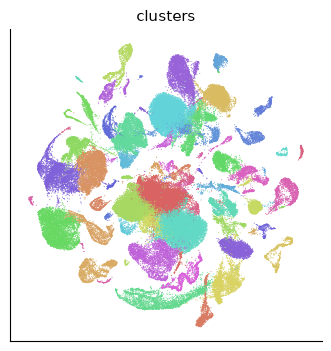

Started: 2026-10-08T11:02:40.522571Z | Wall time: 2.392 s

In [3]:
# Color the prepared atlas embedding by its saved clusters.
ds.plots.embedding(run=run, color_by="clusters", show_legend=False, point_size=0.5)

Each colour marks a cluster of cells with similar RNA profiles. A cluster number is not a cell
type. The source's cell-type annotations remain in `ds.cells`; the clusters shown here come
from the CyteArc analysis. Continue with the smaller [PBMC walkthrough](tutorials/scrna_seq.ipynb) to work
through each step and compare marker genes. For another input format, see [](tutorials/import_and_export.ipynb); for a familiar workflow
translation, see [](scanpy.md) or [](seurat.md).

## Analyze your own RNA-seq data

For a filtered Cell Ranger H5 file, convert the counts to a CyteArc store and run the pipeline:

```python
# Import CyteArc to open and analyze your count store.
import cytearc

# Read the count matrix and its cell and feature identifiers.
reader = cytearc.CrH5Reader("filtered_feature_bc_matrix.h5")

# Write the prepared counts and metadata to the new store.
cytearc.CrToZarr(reader, zarr_loc="analysis.zarr").dump()

# Open the datastore for the following analysis.
ds = cytearc.DataStore("analysis.zarr")

# Run the default RNA analysis and retain its results.
run = ds.pipeline.run(label="baseline")

# Color the new RNA embedding by its selected clusters.
ds.plots.embedding(run=run, color_by="clusters")
```

Use a new or empty output path for conversion. A writer raises `FileExistsError` for a path that
already holds data. Pass `overwrite=True` to replace an earlier conversion that no `DataStore` has
opened; once opened, a store is prepared and is never replaced, so delete it yourself or choose
another path. The pipeline uses CyteArc's default settings for
filtering, feature selection, PCA, neighbours, UMAP, clustering, and marker search. It also scores
cell cycle and doublets. These settings are a starting point;
review [](tutorials/quality_control.ipynb) and the marker evidence before interpreting a new dataset.

`run` holds the results of this analysis. Keep it to make plots and read marker tables without
repeating the computation. Each named run needs a new label; reopen a completed one with
`ds.pipeline.open(label="baseline")`.

For control over individual steps, use `ds.features`, `ds.reduction`, `ds.graph`,
`ds.embeddings`, `ds.clusters`, and `ds.markers`. The
[graph tutorial](tutorials/graph_construction.ipynb) follows this route with explicit inputs and
saved results. These methods use the same computations as the pipeline.